# ЛР3. NB, LR, SVM

In [23]:
import numpy as np 
import pandas as pd 

from sklearn import preprocessing
import matplotlib.pyplot as plt 
plt.rc("font", size=14)
import seaborn as sns
sns.set(style="white") #white background style for seaborn plots
sns.set(style="whitegrid", color_codes=True)

import warnings
warnings.simplefilter(action='ignore')

In [24]:
# Создадим DataFrame train_df из CSV train.csv
train_df = pd.read_csv("./train.csv")

# Создадим DataFrame test_df из CSV test.csv
test_df = pd.read_csv("./test.csv")

train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [25]:
#Посчитайте количество объектов в DF train и test
print(f'Размерность train датасета: {train_df.shape[0]}')
print(f'Размерность test датасета: {test_df.shape[0]}')


Размерность train датасета: 891
Размерность test датасета: 418


<font color=red>  Примечание. В тестовых данных нет целевой переменной (т. е. столбец «Survival» отсутствует), поэтому цель состоит в том, чтобы предсказать эту переменную с использованием различных алгоритмов машинного обучения, таких как логистическая регрессия. </font>

In [26]:
# Проверьте, есть ли в данных train_df пропущенные значения
print("Пропущенные значения в train_df:\n", train_df.isnull().sum())

Пропущенные значения в train_df:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Давайте разберемся с графиой "Age"
Ответьте на вопросы и сделайте следующие дейтсвия

Сколько процентов значений пропущено?
Найдите медиану и среднее значение переменной.
Постойте гистаграмму.
Какое значение больше: медиана или среднее?

In [27]:
missing_age_pct = train_df['Age'].isnull().mean() * 100
print(f"\nПроцент пропущенных значений в Age: {missing_age_pct}%")

age_median = train_df['Age'].median()
age_mean = train_df['Age'].mean()
print(f"Медиана возраста: {age_median}")
print(f"Среднее значение возраста: {age_mean}")


Процент пропущенных значений в Age: 19.865319865319865%
Медиана возраста: 28.0
Среднее значение возраста: 29.69911764705882


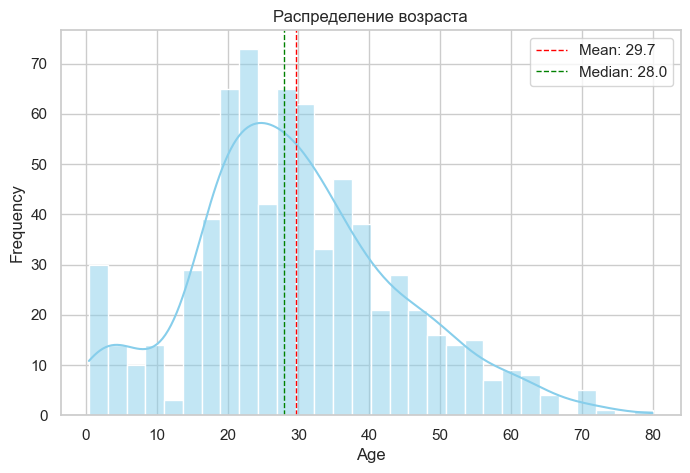

In [28]:
plt.figure(figsize=(8, 5))
sns.histplot(train_df['Age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Распределение возраста")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.axvline(age_mean, color='red', linestyle='dashed', linewidth=1, label=f"Mean: {age_mean:.1f}")
plt.axvline(age_median, color='green', linestyle='dashed', linewidth=1, label=f"Median: {age_median:.1f}")
plt.legend()
plt.show()

Так как график распределения смещён вправа, использование среднего значения может дать нам необъективные результаты из-за заполнения возрастов, которые старше желаемого. Чтобы справиться с этим, мы будем использовать медиану для вменения пропущенных значений.

Давайте разберемся с графиой "Cabin"

Сколько процентов значений пропущено?

In [29]:
missing_cabin_pct = train_df['Cabin'].isnull().mean() * 100
print(f"\nПроцент пропущенных значений в Cabin: {missing_cabin_pct}%")


Процент пропущенных значений в Cabin: 77.10437710437711%


<font color=green>  Если в столбце больше половины пропусков, то он не информативен для нас. В дальнейшем мы его уберем </font>

Давайте разберемся с графиой "Embarked"

Сколько процентов значений пропущено?

In [30]:
missing_embarked_pct = train_df['Embarked'].isnull().mean() * 100
print(f"Процент пропущенных значений в Embarked: {missing_embarked_pct}%")

Процент пропущенных значений в Embarked: 0.22446689113355783%


In [31]:
train_data = train_df.copy()

Основываясь на оценке отсутствующих значений в наборе данных, внесите в данные следующие изменения:

Если в строке отсутствует «Age», вставьте средний возраст.
Если отсутствует «Embarked», замените его на наиболее распространенный порт посадки.
Удалите столбец "Cabin"

In [32]:
train_data['Age'].fillna(age_median, inplace=True)
most_common_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'].fillna(most_common_embarked, inplace=True)
train_data.drop('Cabin', axis=1, inplace=True)

Выполните проверку на пустые значения. Таковых остаться не должно

In [33]:
print("\nОставшиеся пропущенные значения:\n", train_data.isnull().sum())


Оставшиеся пропущенные значения:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


Согласно словарю данных Kaggle, и SibSp, и Parch относятся к путешествиям с семьей. Для простоты (и для учета возможной мультиколлинеарности) я объединим влияние этих переменных в один категориальный предиктор: путешествовал ли этот человек один или нет (0 или 1).
Не забудьте удалить SibSp и Parch (Пока работаем с train_data)

In [34]:
train_data['TravelAlone']= np.where((train_data['SibSp'] == 0) & (train_data['Parch'] == 0), 1, 0)
train_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)

In [35]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,TravelAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,1


также создадим категориальные переменные для класса пассажира ("Pclass"), пола ("Sex") и порта посадки ("Embarked").
Используем функцию pd.get_dummies
Не забудьте удалить колонки, из которых делаете dummie-переменные

In [36]:
training = train_data.copy()
training = pd.get_dummies(training, columns=['Pclass', 'Sex', 'Embarked'])
# training.drop('Pclass')
# training.drop('Sex')
# training.drop('Embarked')

final_train = training
final_train.head()

,PassengerId,Survived,Name,Age,Ticket,Fare,TravelAlone,Pclass_1,Pclass_2,Pclass_3,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,1,0,"Braund, Mr. Owen Harris",22.0,A/5 21171,7.2500,0,False,False,True,False,True,False,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,PC 17599,71.2833,0,True,False,False,True,False,True,False,False
2,3,1,"Heikkinen, Miss. Laina",26.0,STON/O2. 3101282,7.9250,1,False,False,True,True,False,False,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,113803,53.1000,0,True,False,False,True,False,False,False,True
4,5,0,"Allen, Mr. William Henry",35.0,373450,8.0500,1,False,False,True,False,True,False,False,True


Теперь примените те же изменения к тестовым данным.

Применим то же значение для «Возраст» в тестовых данных, что и для моих данных обучения (если отсутствует, возраст = 28).
Уберем «Cabin» из тестовых данных
В переменной порта "Embarked" не было пропущенных значений.
Добавим dummie переменные.
Наконец, заполним 1 пропущенное значение для «Fare» с медианой 14,45.

In [37]:
test_data = test_df.copy()

test_data['Age'].fillna(age_median, inplace=True)
test_data.drop('Cabin', axis=1, inplace=True)
test_data['Fare'].fillna(14.45, inplace=True)
test_data = pd.get_dummies(test_data, columns=['Pclass', 'Sex', 'Embarked'], drop_first=True)
test_data['TravelAlone'] = np.where((test_data['SibSp'] == 0) & (test_data['Parch'] == 0), 1, 0)
test_data.drop(['SibSp', 'Parch'], axis=1, inplace=True)
final_test = test_data
final_test.head()

,PassengerId,Name,Age,Ticket,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,TravelAlone
0,892,"Kelly, Mr. James",34.5,330911,7.8292,False,True,True,True,False,1
1,893,"Wilkes, Mrs. James (Ellen Needs)",47.0,363272,7.0000,False,True,False,False,True,0
2,894,"Myles, Mr. Thomas Francis",62.0,240276,9.6875,True,False,True,True,False,1
3,895,"Wirz, Mr. Albert",27.0,315154,8.6625,False,True,True,False,True,1
4,896,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",22.0,3101298,12.2875,False,True,False,False,True,0


Оцените выживаемость Пассажиров до 16 лет

In [38]:
final_train['IsMinor'] = np.where(final_train['Age'] < 16, 1, 0)
minor_survival_rate = final_train[final_train['IsMinor'] == 1]['Survived'].mean() * 100

print(f"Процент выживших пассажиров младше 16 лет: {minor_survival_rate}%")

Процент выживших пассажиров младше 16 лет: 59.036144578313255%


Учитывая выживаемость пассажиров моложе 16 лет,включим в свой набор данных еще одну категориальную переменную: «IsMinor». Значение 1 - если меньше 16 лет, 0 - если больше

In [39]:
final_test['IsMinor'] = np.where(final_test['Age'] < 16, 1, 0)

Определите самый безопасный класс
Определите, кому удаолсь выжить с большей вероятностью: кто путешествовал в одиночку или нет

In [40]:
class_survival = train_df.groupby('Pclass')['Survived'].mean()
print("\nСредняя выживаемость по классам:")
print(class_survival)
safest_class = class_survival.idxmax()
print(f"Самый безопасный класс: {safest_class}")

travel_alone_survival = final_train.groupby('TravelAlone')['Survived'].mean()
print("\nВыживаемость в зависимости от того, путешествовал ли один:")
print(travel_alone_survival)

if travel_alone_survival[0] > travel_alone_survival[1]:
    print("Пассажиры, путешествующие не одни, выживали чаще.")
else:
    print("Пассажиры, путешествующие одни, выживали чаще.")


Средняя выживаемость по классам:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Самый безопасный класс: 1

Выживаемость в зависимости от того, путешествовал ли один:
TravelAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64
Пассажиры, путешествующие не одни, выживали чаще.



##  Выбор признаков для анализа


### Рекурсивное устранение признаков

рекурсивное исключение функций (RFE) заключается в выборе функций путем рекурсивного рассмотрения все меньших и меньших наборов функций. Во-первых, оценщик обучается на начальном наборе признаков, и важность каждого признака определяется либо с помощью атрибута «coef_», либо с помощью атрибута «feature_importances_». Затем наименее важные функции удаляются из текущего набора функций. Эта процедура рекурсивно повторяется для сокращенного набора до тех пор, пока в конечном итоге не будет достигнуто желаемое количество функций для выбора.

Изучите материалы ниже

 <br>
 https://www.helenkapatsa.ru/kross-validatsiia/ <br>
 https://www.codecamp.ru/blog/cross-validation-k-fold/ <br>
http://scikit-learn.org/stable/modules/feature_selection.html <br>

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

cols = ["Age","Fare","TravelAlone","Pclass_1","Pclass_2","Embarked_C","Embarked_S","Sex_male","IsMinor"] 
X = final_train[cols]
y = final_train['Survived']
# Создайте logreg и вычислите важность функций
model = LogisticRegression(max_iter=1000)
# создайте модель RFE и выберите 8 атрибутов

rfe = RFE(estimator=model, n_features_to_select=8)
rfe = rfe.fit(X, y)
# резюмируем  выбор атрибутов
print('Selected features: %s' % list(X.columns[rfe.support_]))

Selected features: ['Age', 'TravelAlone', 'Pclass_1', 'Pclass_2', 'Embarked_C', 'Embarked_S', 'Sex_male', 'IsMinor']


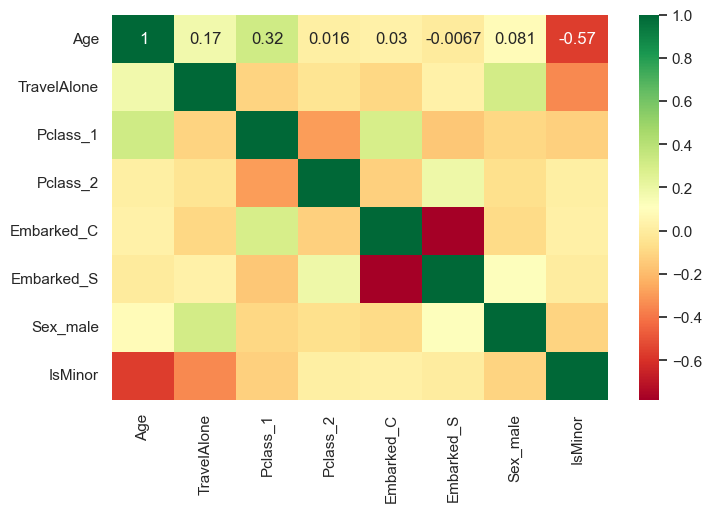

In [44]:
Selected_features = ['Age', 'TravelAlone', 'Pclass_1', 'Pclass_2', 'Embarked_C', 
                     'Embarked_S', 'Sex_male', 'IsMinor']
X = final_train[Selected_features]

plt.subplots(figsize=(8, 5))
sns.heatmap(X.corr(), annot=True, cmap="RdYlGn")
plt.show()

## представьте, перед вами стоит задача оценки качества работы модели машинного обучения и сравнения таких моделей межд собой

идея: разделение датасета на выборку для обучения и тестирования

### Оценка модели на основе простого разделения train/test с использованием функции `train_test_split()`

In [45]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score 
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, auc, log_loss

# create X (features) and y (response)
X = final_train[Selected_features]
y = final_train['Survived']

# можно использовать разделение обучения/тестирования с разными значениями random_state
# мы можем изменить значения random_state, которые изменят показатели точности
# результаты сильно меняются, поэтому результаты тестирования являются оценкой с высокой дисперсией
# test_size разделяет выборку на тестовую и убучающую в соотношении 20/80
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# check classification scores of logistic regression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_pred_proba = logreg.predict_proba(X_test)[:, 1]
[fpr, tpr, thr] = roc_curve(y_test, y_pred_proba)
print('Train/Test split results:')
print(logreg.__class__.__name__+" accuracy is %2.3f" % accuracy_score(y_test, y_pred))
print(logreg.__class__.__name__+" log_loss is %2.3f" % log_loss(y_test, y_pred_proba))
print(logreg.__class__.__name__+" auc is %2.3f" % auc(fpr, tpr))

Train/Test split results:
LogisticRegression accuracy is 0.788
LogisticRegression log_loss is 0.503
LogisticRegression auc is 0.839


### Оценка модели на основе K-fold cross-validation с использованием функции cross_val_score()

Кросс-валидация — это метод, предназначенный для оценки качества работы модели, широко применяемый в машинном обучении. Он помогает сравнить между собой различные модели и выбрать наилучшую для конкретной задачи


Метод k-Fold чаще всего имеют в виду, когда говорят о кросс-валидации. Он является обобщением метода hold-out и представляет из себя следующий алгоритм:

1. Фиксируется некоторое целое число (обычно от 5 до 10), меньшее числа семплов в датасете.
2. Датасет разбивается на одинаковых частей (в последней части может быть меньше семплов, чем в остальных). Эти части называются фолдами.
3. Далее происходит k итераций, во время каждой из которых один фолд выступает в роли тестового множества, а объединение остальных — в роли тренировочного. Модель учится на k -1 фолде и тестируется на оставшемся.
4. Финальный скор модели получается либо усреднением получившихся тестовых результатов, либо измеряется на отложенном тестовом множестве, не участвовавшем в кросс-валидации.

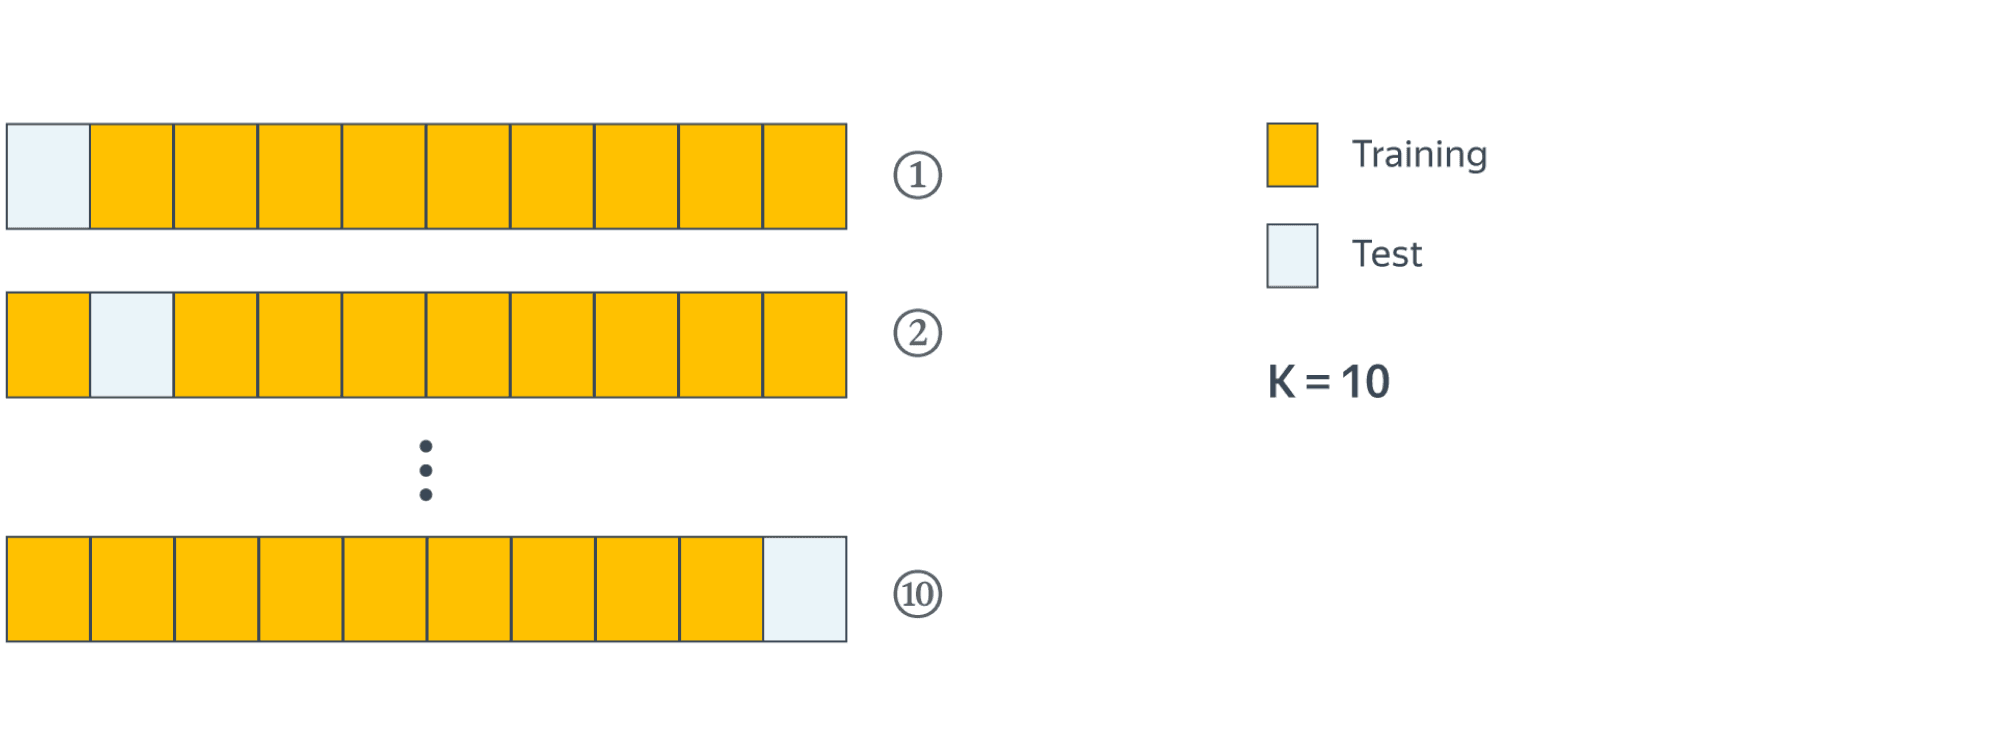

Метод stratified k-Fold — это метод k-Fold, использующий стратификацию при разбиении на фолды: каждый фолд содержит примерно такое же соотношение классов, как и всё исходное множество (подробнее о стратификации говорилось выше). Такой подход может потребоваться в случае, например, очень несбалансированного соотношения классов, когда при обычном random split некоторые фолды могут либо вообще не содержать семплов каких-то классов, либо содержать их слишком мало.



Что такое logloss?


Допустим, модель предсказывает вероятности [0,8, 0,4, 0,1] для трех домов. Первые два дома были проданы, а последний не продан. Таким образом, фактические результаты могут быть представлены численно как [1, 1, 0].

Давайте рассмотрим эти прогнозы по одному, чтобы итеративно вычислить функцию правдоподобия.

Первый дом продан, и модель сказала, что это возможно с вероятностью 80%. Итак, функция правдоподобия после просмотра одного прогноза равна 0,8.

Второй дом продан, и модель сказала, что это возможно с вероятностью 40%. Существует правило вероятности, согласно которому вероятность множества независимых событий является произведением их индивидуальных вероятностей. Итак, мы получаем общую вероятность первых двух прогнозов, умножая связанные с ними вероятности. Это 0,8 * 0,4, что получается 0,32.

Теперь мы переходим к нашему третьему предсказанию. Этот дом не был продан. Модель сказала, что вероятность продажи составляет 10%. Это означает, что с вероятностью 90% он не будет продан. Таким образом, в соответствии с моделью наблюдаемый результат отказа от продажи имел вероятность 90%. Итак, умножаем предыдущий результат 0,32 на 0,9.

Мы могли бы пройти через все наши предсказания. Каждый раз мы находили вероятность, связанную с фактически произошедшим результатом, и умножали ее на предыдущий результат. Это вероятность.

От вероятности к log loss

Каждое предсказание находится в диапазоне от 0 до 1.

Логарифмическая потеря указывает, насколько близка вероятность предсказания к соответствующему истинному значению (0 или 1 в случае двоичной классификации). Чем больше прогнозируемая вероятность отклоняется от фактического значения, тем выше значение логарифма потерь



In [46]:
# 10-fold cross-validation logistic regression
logreg = LogisticRegression()
# Используем cross_val_score function
# Мы передаём полные X and y, а не X_train и y_train, функция сама разбивает данные
# cv=10 for 10 folds
# scoring = {'accuracy', 'neg_log_loss', 'roc_auc'} в качестве метрик оценивания результата (есть и другие)
scores_accuracy = cross_val_score(logreg, X, y, cv=10, scoring='accuracy')
scores_log_loss = cross_val_score(logreg, X, y, cv=10, scoring='neg_log_loss')
scores_auc = cross_val_score(logreg, X, y, cv=10, scoring='roc_auc')
print('K-fold cross-validation results:')
print(logreg.__class__.__name__+" average accuracy is %2.3f" % scores_accuracy.mean())
print(logreg.__class__.__name__+" average log_loss is %2.3f" % -scores_log_loss.mean())
print(logreg.__class__.__name__+" average auc is %2.3f" % scores_auc.mean())

K-fold cross-validation results:
LogisticRegression average accuracy is 0.800
LogisticRegression average log_loss is 0.454
LogisticRegression average auc is 0.850


### Оценка модели на основе K-fold cross-validation с использованием функции cross_validate()

In [47]:
from sklearn.model_selection import cross_validate

scoring = {'accuracy': 'accuracy', 'log_loss': 'neg_log_loss', 'auc': 'roc_auc'}

modelCV = LogisticRegression()

results = cross_validate(modelCV, X, y, cv=10, scoring=list(scoring.values()), 
                         return_train_score=False)

print('K-fold cross-validation results:')
for sc in range(len(scoring)):
    print(modelCV.__class__.__name__+" average %s: %.3f (+/-%.3f)" % (list(scoring.keys())[sc], -results['test_%s' % list(scoring.values())[sc]].mean()
                               if list(scoring.values())[sc]=='neg_log_loss' 
                               else results['test_%s' % list(scoring.values())[sc]].mean(), 
                               results['test_%s' % list(scoring.values())[sc]].std()))

K-fold cross-validation results:
LogisticRegression average accuracy: 0.800 (+/-0.025)
LogisticRegression average log_loss: 0.454 (+/-0.040)
LogisticRegression average auc: 0.850 (+/-0.030)



Формула Байеса


$$
P (A | B) = \frac{P ( B ∣ A ) P ( A )}{P ( B )}
$$


    где

        P ( A ) P(A) — априорная вероятность гипотезы A (смысл такой терминологии см. ниже);
        P ( A ∣ B ) — вероятность гипотезы A при наступлении события B (апостериорная вероятность);
        P ( B ∣ A )  — вероятность наступления события B при истинности гипотезы A;
        P ( B ) P(B) — полная вероятность наступления события B.



In [48]:
import matplotlib.pyplot as plt
from scipy.stats.stats import pearsonr
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [49]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

GaussianNB()

In [50]:

def cross_validate(estimator, train, validation):
    X_train = train[0]
    Y_train = train[1]
    X_val = validation[0]
    Y_val = validation[1]
    train_predictions = classifier.predict(X_train)
    train_accuracy = accuracy_score(train_predictions, Y_train)
    train_recall = recall_score(train_predictions, Y_train)
    train_precision = precision_score(train_predictions, Y_train)

    val_predictions = classifier.predict(X_val)
    val_accuracy = accuracy_score(val_predictions, Y_val)
    val_recall = recall_score(val_predictions, Y_val)
    val_precision = precision_score(val_predictions, Y_val)

    print('Model metrics')
    print('Accuracy  Train: %.2f, Validation: %.2f' % (train_accuracy, val_accuracy))
    print('Recall    Train: %.2f, Validation: %.2f' % (train_recall, val_recall))
    print('Precision Train: %.2f, Validation: %.2f' % (train_precision, val_precision))
    
cross_validate(classifier, (X_train, y_train), (X_test, y_test))

Model metrics
Accuracy  Train: 0.78, Validation: 0.77
Recall    Train: 0.68, Validation: 0.76
Precision Train: 0.78, Validation: 0.68


## SVM

In [52]:
from sklearn.svm import SVC
# Declaring the SVC with no tunning
classifier = SVC()

# Fitting the data. This is where the SVM will learn
classifier.fit(X_train, y_train)

# Predicting the result and giving the accuracy
score = classifier.score(X_test, y_test)

print(score)

0.5698324022346368


In [53]:
#Посчитайте score, если train set будет состоять только из 3 переменных: ['Sex', 'Age', 'Pclass']

cols = ['Sex', 'Age', 'Pclass']
df = train_df[cols + ['Survived']].copy()
df = pd.get_dummies(df, columns=['Sex', 'Pclass'], drop_first=True)
df.dropna(inplace=True)
X = df.drop('Survived', axis=1)
y = df['Survived']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classifier = SVC()
classifier.fit(X_train, y_train)

score = classifier.score(X_test, y_test)
print(f"Accuracy using ['Sex', 'Age', 'Pclass']: {score:.2f}")

Accuracy using ['Sex', 'Age', 'Pclass']: 0.60
